# BRAMBLE — Predicting Shrub Biomass from Height & Crown Diameter

**The idea in one sentence:** instead of measuring biomass by cutting down a tree and weighing it, we predict it from two easy field measurements — height (Ht) and crown diameter (CD) — using a model that also tells us *how confident* it is.

**Why "Bayesian"?** A normal model gives you one number: "this tree weighs 12 kg." A Bayesian model gives you a whole range: "this tree most likely weighs 12 kg, but could reasonably be anywhere from 8 kg to 16 kg." That range is the useful part — it tells us how much to trust the prediction.

**Structure:**
1. Data, and why we work in log space
2. Train / test split
3. Model (hierarchy, non-centered form, Normal likelihood)
4. Fit, check convergence, correct back-transformation bias
5. Simulate predictions, check calibration on training data
6. Per-species performance
7. Check on the held-out test set
8. **Normal vs Student-t** — one combined comparison, using both LOO and cross-validation together
9. Predict new trees

## Step 1 — Load libraries

In [1]:
import numpy as np                     # numerical arrays and math (log, exp, percentiles, etc.)
import pandas as pd                    # loading and manipulating the tree data table (Data Frames)
import matplotlib.pyplot as plt        # drawing plots and figures
import seaborn as sns                  # nicer-looking statistical plots, built on top of matplotlib
import pymc as pm                      # the Bayesian modeling library -- defines and fits the model
import pytensor.tensor as pt           # the math engine PyMC uses internally during fitting
import arviz as az                     # tools for inspecting/summarizing Bayesian model results (R-hat, ESS, etc.)
from sklearn.metrics import r2_score, mean_squared_error   # standard accuracy metrics (R2, RMSE)
from sklearn.model_selection import train_test_split, StratifiedKFold

RNG_SEED = 42   # fixes randomness so results are reproducible every time we run this
sns.set_style("whitegrid")   # sets a clean default look for all plots

g++ not available, if using conda: `conda install gxx`


## Step 2 — Load and clean the data

In [2]:
df = pd.read_csv("BIOMASS_ALLOMETRY.csv", sep=",")
df = df[df["Species"].isin(["Olive", "Argan", "Schinus", "Carob"])].copy()

df["CD"] = df[["CD1", "CD2"]].mean(axis=1)
df["BD"] = df[["BD1", "BD2"]].mean(axis=1)

df = df.reset_index(drop=True)

print(f"Total trees: {len(df)}")
df[["Species", "Ht", "CD", "BD", "Total_AGB"]].head()

Total trees: 204


,Species,Ht,CD,BD,Total_AGB
0,Argan,2.15,3.050,18.50,25.165767
1,Argan,1.90,3.300,18.50,33.866059
2,Argan,2.90,4.750,19.00,56.430586
3,Argan,2.45,3.650,13.75,25.337144
4,Argan,1.70,2.275,13.50,15.228814


## Step 3 — Why we use LOG values

Biomass grows as a power law with tree size, not a straight line — the raw relationship curves. Taking the log of both sides straightens that curve into something a linear model can fit, and it sidesteps the fact that raw biomass can never be negative, a requirement a Normal likelihood needs but raw biomass can't satisfy.

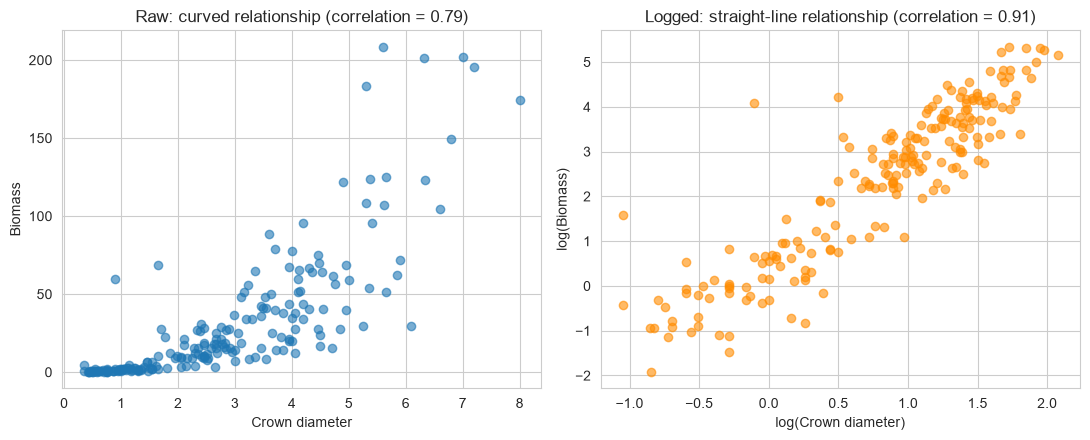

In [3]:
df["logAGB"] = np.log(df["Total_AGB"])
df["logHt"] = np.log(df["Ht"])
df["logCD"] = np.log(df["CD"])

raw_corr = df["CD"].corr(df["Total_AGB"], method="pearson")
log_corr = df["logCD"].corr(df["logAGB"], method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(df["CD"], df["Total_AGB"], alpha=0.6)
axes[0].set_title(f"Raw: curved relationship (correlation = {raw_corr:.2f})")
axes[0].set_xlabel("Crown diameter"); axes[0].set_ylabel("Biomass")

axes[1].scatter(df["logCD"], df["logAGB"], alpha=0.6, color="darkorange")
axes[1].set_title(f"Logged: straight-line relationship (correlation = {log_corr:.2f})")
axes[1].set_xlabel("log(Crown diameter)"); axes[1].set_ylabel("log(Biomass)")
plt.tight_layout()
plt.show()

## Step 4 — Train / test split

80/20, stratified by species so each species keeps the same proportion in both groups. This gives a set of trees genuinely never seen during fitting, used in Step 9.

In [4]:
PREDICTORS = ["Ht", "CD"]

unique_species = df["Species"].unique()
species_to_idx = {sp: i for i, sp in enumerate(unique_species)}
n_species = len(unique_species)
nvars = len(PREDICTORS)

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=df["Species"], random_state=RNG_SEED
)
df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

X_log = np.log(df_train[PREDICTORS].values)
Y_log = np.log(df_train["Total_AGB"].values)
species_idx = df_train["Species"].map(species_to_idx).values

print(f"Training trees: {len(df_train)}  |  Test trees (hidden from model): {len(df_test)}")

Training trees: 163  |  Test trees (hidden from model): 41


## Step 5 — The prediction formula (one class, used everywhere)

In [5]:
class BRAMBLE:
    def __init__(self, params, inference=False):
        self.lib = pt if inference else np
        self.params = params

    def predict_log(self, X_log, species_idx):
        betas = self.params["betas"][species_idx]
        beta0 = self.params["beta0"][species_idx]
        return self.lib.sum(X_log * betas, axis=1) + beta0

    def predict_biomass(self, X_log, species_idx, correction=None):
        pred = self.lib.exp(self.predict_log(X_log, species_idx))
        if correction is not None:
            pred = pred * correction
        return pred

## Step 6 — Fit the model

**Hierarchy:** each species gets its own beta0/betas, drawn from a shared population-level distribution. A species with few trees leans on the group average — the model decides how much pooling by estimating the shared spread from the data itself.

**Non-centered form:** the species-level coefficients are written as a simple noise term, combined with the shared mean/spread afterward — mathematically identical, just easier for the sampler to explore. A numerical trick, not a modeling choice.

**Likelihood:** the error is given a Normal shape here. The only claim being made about it is a mean and a variance — nothing more specific. Given just that, Normal is the mathematically least-assuming distribution consistent with it (Maximum Entropy). Step 9 tests whether the data actually needs something richer (Student-t).

In [6]:
def fit_bramble(X_log_in, species_idx_in, Y_log_in, likelihood="normal", seed=RNG_SEED):
    with pm.Model() as m:
        mu_beta0    = pm.Normal("mu_beta0", 0, 1)
        sigma_beta0 = pm.HalfNormal("sigma_beta0", 1)
        mu_betas    = pm.Normal("mu_betas", 1, 0.5, shape=nvars)
        sigma_betas = pm.HalfNormal("sigma_betas", 0.5, shape=nvars)

        z_beta0 = pm.Normal("z_beta0", 0, 1, shape=n_species)
        beta0   = pm.Deterministic("beta0", mu_beta0 + sigma_beta0 * z_beta0)
        z_betas = pm.Normal("z_betas", 0, 1, shape=(n_species, nvars))
        betas   = pm.Deterministic("betas", mu_betas + sigma_betas * z_betas)

        bramble_obj = BRAMBLE({"betas": betas, "beta0": beta0}, inference=True)
        mu = bramble_obj.predict_log(X_log_in, species_idx_in)

        sigma = pm.HalfNormal("sigma", 1)
        if likelihood == "normal":
            pm.Normal("obs", mu=mu, sigma=sigma, observed=Y_log_in)
        else:
            nu = pm.Gamma("nu", alpha=2, beta=0.1)
            pm.StudentT("obs", nu=nu, mu=mu, sigma=sigma, observed=Y_log_in)

        tr = pm.sample(1000, tune=1500, chains=4, target_accept=0.95,
                        random_seed=seed, progressbar=False)
    return m, tr

model, trace = fit_bramble(X_log, species_idx, Y_log, likelihood="normal")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta0, sigma_beta0, mu_betas, sigma_betas, z_beta0, z_betas, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 11 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


## Step 7 — Did the fit actually work?

**R-hat** near 1.00 means independent chains agree. **ESS** in the thousands means enough independent information was gathered. **Divergences** near zero means the sampler explored safely.

In [7]:
summary = az.summary(trace, var_names=["beta0", "betas", "sigma"]).apply(pd.to_numeric, errors="coerce")
divergences = int(trace.sample_stats["diverging"].sum())
print(f"Divergences : {divergences}")
print(f"Max R-hat   : {summary['r_hat'].max():.3f}")
print(f"Min ESS     : {summary['ess_bulk'].min():.0f}")
summary

Divergences : 3
Max R-hat   : 1.002
Min ESS     : 3212


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0[0],0.144,0.111,-0.03,0.32,4470,3721,1.00,0.0017,0.0014
beta0[1],0.088,0.182,-0.21,0.38,4360,3224,1.00,0.0028,0.0033
beta0[2],-0.011,0.191,-0.35,0.26,3509,3542,1.00,0.0032,0.0027
beta0[3],0.043,0.126,-0.16,0.24,4182,3873,1.00,0.0019,0.0018
"betas[0, 0]",1.793,0.218,1.5,2.1,4024,3060,1.00,0.0034,0.0034
"betas[0, 1]",1.153,0.168,0.89,1.4,4529,3465,1.00,0.0025,0.0026
"betas[1, 0]",1.643,0.235,1.3,2,3266,2810,1.00,0.0042,0.0039
"betas[1, 1]",1.247,0.197,0.97,1.6,3366,3144,1.00,0.0034,0.0034
"betas[2, 0]",1.592,0.227,1.2,1.9,3212,3012,1.00,0.004,0.0032
"betas[2, 1]",1.019,0.193,0.7,1.3,3298,2631,1.00,0.0034,0.0029


## Step 8 — Bias correction, then simulate the full predictive range

`exp()` of a log-scale prediction systematically underestimates the real value (Jensen's inequality) — fixed with a per-species correction factor measured from the residuals.

Then, for every posterior sample, we compute a predicted mean AND add random noise from sigma (the tree-to-tree variation Ht/CD can't explain). Sorting the results gives P10, P50, P90 — the range covering the middle 80% of simulated guesses.

In [8]:
np.random.seed(RNG_SEED)

def correction_from_fit(trace_obj, X_log_in, species_idx_in, Y_log_in, species_series):
    b0m = trace_obj.posterior["beta0"].mean(("chain", "draw")).values
    bsm = trace_obj.posterior["betas"].mean(("chain", "draw")).values
    bm = BRAMBLE({"betas": bsm, "beta0": b0m}, inference=False)
    resid = Y_log_in - bm.predict_log(X_log_in, species_idx_in)
    return {sp: np.mean(np.exp(resid[species_series.values == sp])) for sp in unique_species}

def predict_with_uncertainty(trace_obj, X_log_in, species_idx_in, correction_in):
    b0 = trace_obj.posterior["beta0"].values.reshape(-1, n_species)
    bs = trace_obj.posterior["betas"].values.reshape(-1, n_species, nvars)
    sg = trace_obj.posterior["sigma"].values.reshape(-1)
    sims = np.zeros((b0.shape[0], len(X_log_in)))
    for s in range(b0.shape[0]):
        bb = BRAMBLE({"betas": bs[s], "beta0": b0[s]}, inference=False)
        mu_log = bb.predict_log(X_log_in, species_idx_in)
        sims[s] = np.exp(mu_log + np.random.normal(0, sg[s], size=len(X_log_in))) * correction_in
    return sims

def coverage_of(sims, truth):
    p10, p50, p90 = np.percentile(sims, [10, 50, 90], axis=0)
    cov = (((truth >= p10) & (truth <= p90)).mean()) * 100
    return cov, p10, p50, p90

correction_by_species = correction_from_fit(trace, X_log, species_idx, Y_log, df_train["Species"])
print("Correction factor by species (should be close to 1.0):")
for sp, val in correction_by_species.items():
    print(f"  {sp}: {val:.3f}")

corr_per_tree = df_train["Species"].map(correction_by_species).values
simulated = predict_with_uncertainty(trace, X_log, species_idx, corr_per_tree)
cov_train, p10, p50, p90 = coverage_of(simulated, df_train["Total_AGB"].values)
df_train["pred_10"], df_train["pred_50"], df_train["pred_90"] = p10, p50, p90

r2_train = r2_score(df_train["Total_AGB"], p50)
rmse_train = np.sqrt(mean_squared_error(df_train["Total_AGB"], p50))
cv_pct_train = (rmse_train / df_train["Total_AGB"].mean()) * 100
print(f"\nTRAIN -- R2: {r2_train:.3f}  |  RMSE: {rmse_train:.2f} kg  |  CV: {cv_pct_train:.1f}%  |  Coverage: {cov_train:.1f}%  (target ~80%)")

Correction factor by species (should be close to 1.0):
  Argan: 1.424
  Carob: 1.083
  Schinus: 1.140
  Olive: 1.196

TRAIN -- R2: 0.808  |  RMSE: 18.18 kg  |  CV: 58.4%  |  Coverage: 82.2%  (target ~80%)


### Calibration check

**Coverage** = % of trees whose real biomass lands inside their own P10-P90 range. Below ~70% = overconfident (range too narrow). Above ~95% = underconfident (range too wide).

The histogram goes further: for each tree, where does the real value land as a percentile within its own simulated distribution? If well-calibrated, this should scatter evenly across 0-100 — a lopsided histogram reveals a pattern the single coverage number can hide.

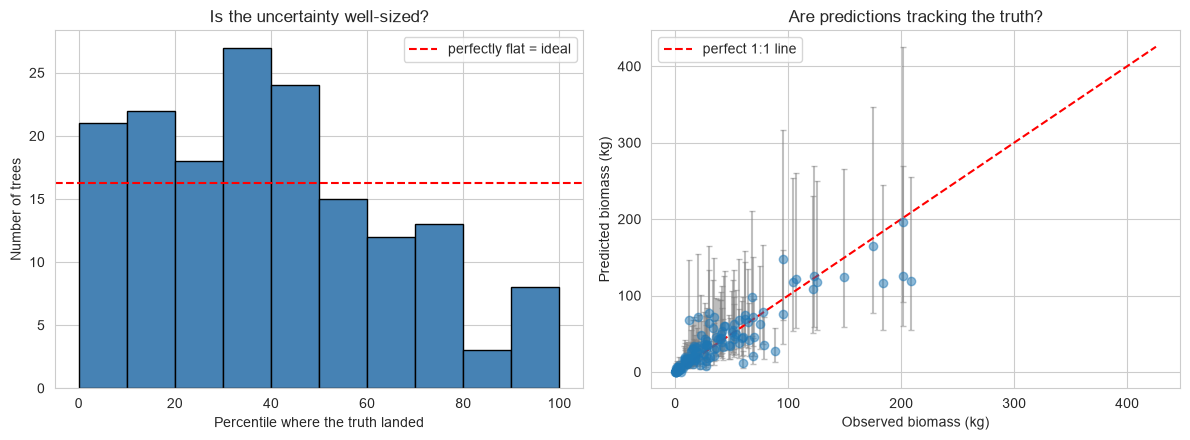

In [9]:
truth_pct = np.array([(simulated[:, i] < df_train["Total_AGB"].values[i]).mean() * 100 for i in range(len(df_train))])
df_train["truth_percentile"] = truth_pct

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(truth_pct, bins=10, range=(0, 100), color="steelblue", edgecolor="black")
axes[0].axhline(len(df_train) / 10, color="red", linestyle="--", label="perfectly flat = ideal")
axes[0].set_xlabel("Percentile where the truth landed"); axes[0].set_ylabel("Number of trees")
axes[0].set_title("Is the uncertainty well-sized?")
axes[0].legend()

axes[1].errorbar(df_train["Total_AGB"], p50, yerr=[p50-p10, p90-p50], fmt="o", alpha=0.5, ecolor="gray", capsize=2)
max_val = max(df_train["Total_AGB"].max(), p90.max())
axes[1].plot([0, max_val], [0, max_val], "r--", label="perfect 1:1 line")
axes[1].set_xlabel("Observed biomass (kg)"); axes[1].set_ylabel("Predicted biomass (kg)")
axes[1].set_title("Are predictions tracking the truth?")
axes[1].legend()
plt.tight_layout()
import os
os.makedirs("report_figures", exist_ok=True)
plt.savefig("report_figures/calibration.png", dpi=130, bbox_inches="tight")
plt.show()

## Step 9 — Per-species performance

An overall number can hide a species-specific weakness.

In [10]:
rows = []
for sp in unique_species:
    sub = df_train[df_train["Species"] == sp]
    inside_sp = (sub["Total_AGB"] >= sub["pred_10"]) & (sub["Total_AGB"] <= sub["pred_90"])
    rmse_sp = np.sqrt(mean_squared_error(sub["Total_AGB"], sub["pred_50"]))
    rows.append({
        "Species": sp,
        "R2": round(r2_score(sub["Total_AGB"], sub["pred_50"]), 3),
        "RMSE": round(rmse_sp, 2),
        "CV %": round((rmse_sp / sub["Total_AGB"].mean()) * 100, 1),
        "Coverage %": round(inside_sp.mean() * 100, 1),
        "N trees": len(sub),
    })

perf = pd.DataFrame(rows)
print(perf)
print("\nArgan shows a low R2 because Ht and CD alone carry little information for it -- adding basal diameter (BD) is the known fix, not yet applied here.")

   Species     R2   RMSE   CV %  Coverage %  N trees
0    Argan  0.184  16.75  112.4        64.7       34
1    Carob  0.830  21.41   39.9        92.1       38
2  Schinus  0.721  24.17   56.2        81.0       42
3    Olive  0.923   6.96   47.2        87.8       49

Argan shows a low R2 because Ht and CD alone carry little information for it -- adding basal diameter (BD) is the known fix, not yet applied here.


### Overall + per-species: observed vs predicted -- summary

**What this section does.** Steps 6-9 already gave us the pieces separately: the fitted model (Step 6), whether the MCMC sampler actually converged (Step 7), the bias-corrected predictions with their P10-P90 uncertainty range (Step 8), and one performance number per species (Step 9). This section puts them together into a single readable check: for every tree, does the predicted range actually bracket the real biomass, and does that hold up **within each species separately**, not just on average?

**Why per species, not just overall.** An overall R2/coverage number can hide a species-specific weakness -- a few species predicted almost perfectly can compensate for one species predicted badly, and the overall number would still look fine. Splitting the same predictions out by species is the only way to see that.

**How to read the numbers below:**
- **R2** -- fraction of the variation in real biomass that the model's median prediction explains (1.0 = perfect, 0 = no better than guessing the mean).
- **RMSE** -- typical prediction error, in kg.
- **CV%** -- RMSE relative to the average biomass of that species; makes species of very different sizes (e.g. small Argan vs large Olive) comparable on the same relative scale.
- **Coverage** -- % of trees whose real biomass actually falls inside their own predicted P10-P90 range. Target ~80%, by construction of a P10-P90 interval.

**How to read the plot below:** each dot is one tree -- observed biomass (x-axis) against the model's median prediction (y-axis), with a vertical bar showing its P10-P90 range. The red dashed line is "perfect prediction" (observed = predicted). A well-behaved species has its dots hugging that line with narrow, honest error bars; a struggling species (this will be Argan) shows dots scattered further from the line, and/or bars that are wide relative to the tree's own size.

===== OVERALL PERFORMANCE (all species combined) =====
R2       : 0.808
RMSE     : 18.18 kg
CV%      : 58.4%   (RMSE relative to mean biomass)
Coverage : 82.2%   (target ~80%)

===== PER-SPECIES PERFORMANCE =====
Species    R2  RMSE  CV %  Coverage %  N trees
  Argan 0.184 16.75 112.4        64.7       34
  Carob 0.830 21.41  39.9        92.1       38
Schinus 0.721 24.17  56.2        81.0       42
  Olive 0.923  6.96  47.2        87.8       49

Strongest fit: Olive (R2=0.923)   Weakest fit: Argan (R2=0.184)



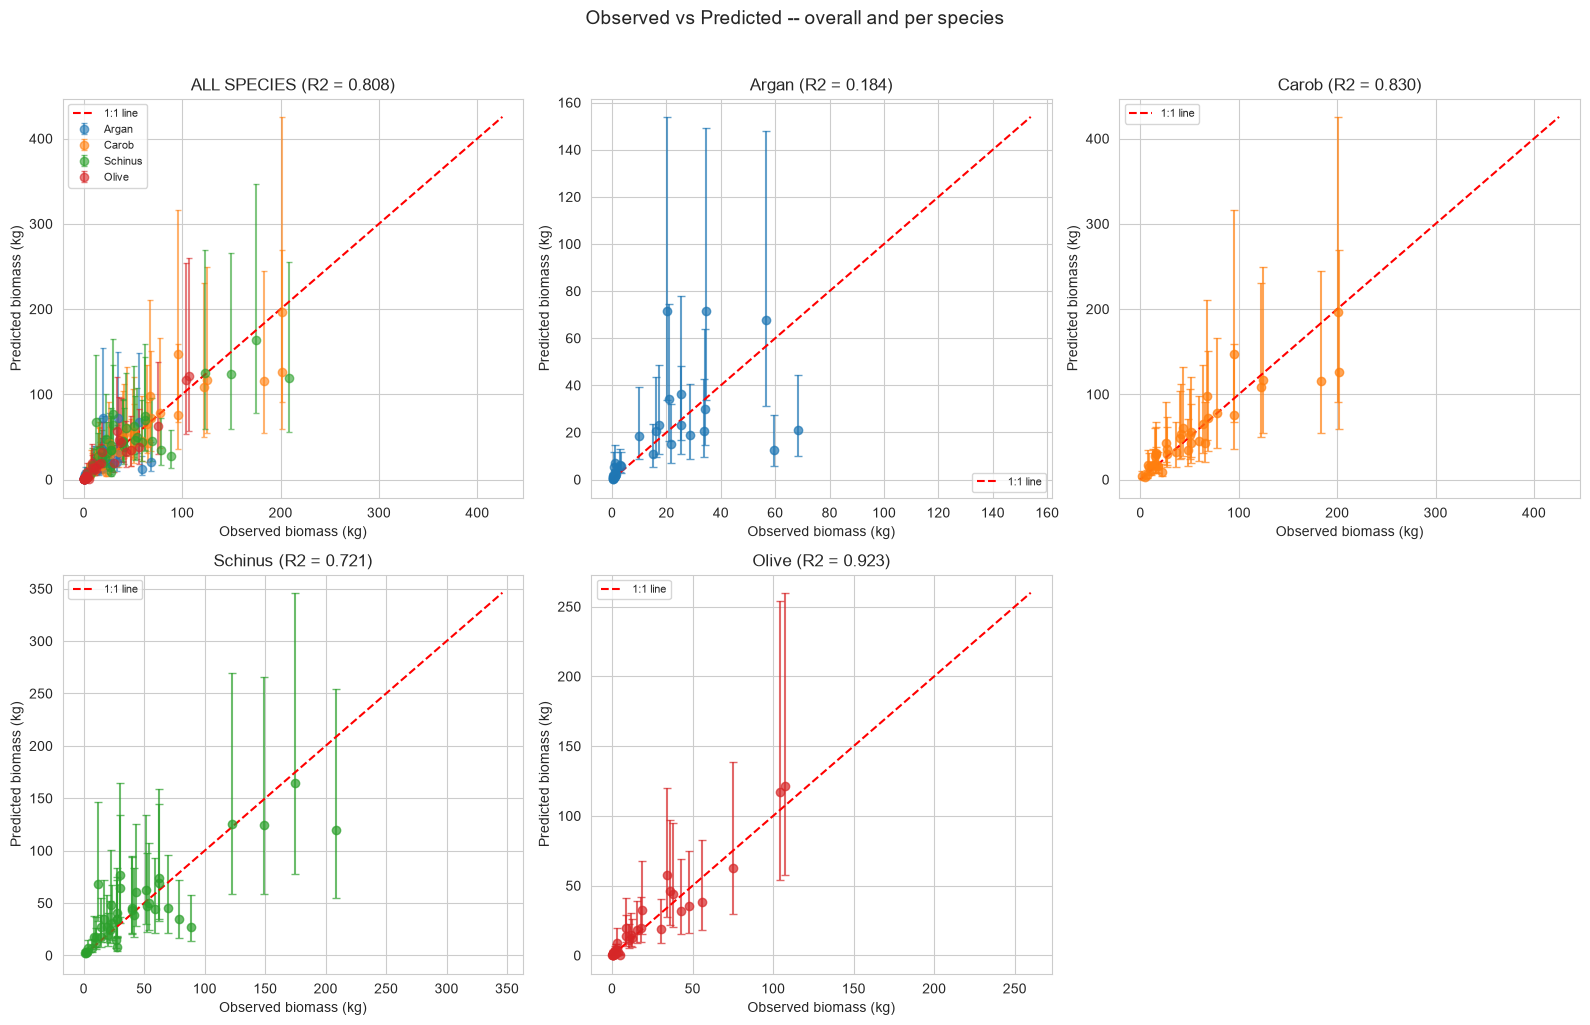

In [11]:
species_palette = dict(zip(unique_species, sns.color_palette("tab10", n_species)))

print("===== OVERALL PERFORMANCE (all species combined) =====")
print(f"R2       : {r2_train:.3f}")
print(f"RMSE     : {rmse_train:.2f} kg")
print(f"CV%      : {cv_pct_train:.1f}%   (RMSE relative to mean biomass)")
print(f"Coverage : {cov_train:.1f}%   (target ~80%)")
print()

print("===== PER-SPECIES PERFORMANCE =====")
print(perf.to_string(index=False))
print()

weakest = perf.loc[perf["R2"].idxmin(), "Species"]
strongest = perf.loc[perf["R2"].idxmax(), "Species"]
print(f"Strongest fit: {strongest} (R2={perf.loc[perf['Species']==strongest,'R2'].values[0]})   "
      f"Weakest fit: {weakest} (R2={perf.loc[perf['Species']==weakest,'R2'].values[0]})")
print()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

ax = axes[0]
for sp in unique_species:
    mask = df_train["Species"] == sp
    ax.errorbar(
        df_train.loc[mask, "Total_AGB"], p50[mask],
        yerr=[p50[mask] - p10[mask], p90[mask] - p50[mask]],
        fmt="o", alpha=0.6, capsize=2, label=sp, color=species_palette[sp]
    )
max_val = max(df_train["Total_AGB"].max(), p90.max())
ax.plot([0, max_val], [0, max_val], "r--", label="1:1 line")
ax.set_xlabel("Observed biomass (kg)")
ax.set_ylabel("Predicted biomass (kg)")
ax.set_title(f"ALL SPECIES (R2 = {r2_train:.3f})")
ax.legend(fontsize=8)

for ax, sp in zip(axes[1:], unique_species):
    mask = (df_train["Species"] == sp).values
    obs_sp = df_train.loc[mask, "Total_AGB"]
    pred_sp = p50[mask]
    r2_sp = r2_score(obs_sp, pred_sp)

    ax.errorbar(
        obs_sp, pred_sp,
        yerr=[pred_sp - p10[mask], p90[mask] - pred_sp],
        fmt="o", alpha=0.7, capsize=3, color=species_palette[sp]
    )
    max_val_sp = max(obs_sp.max(), p90[mask].max())
    ax.plot([0, max_val_sp], [0, max_val_sp], "r--", label="1:1 line")
    ax.set_xlabel("Observed biomass (kg)")
    ax.set_ylabel("Predicted biomass (kg)")
    ax.set_title(f"{sp} (R2 = {r2_sp:.3f})")
    ax.legend(fontsize=8)

for ax in axes[1 + n_species:]:
    ax.axis("off")

plt.suptitle("Observed vs Predicted -- overall and per species", y=1.02, fontsize=14)
plt.tight_layout()
import os
os.makedirs("report_figures", exist_ok=True)
plt.savefig("report_figures/obs_vs_pred_per_species.png", dpi=130, bbox_inches="tight")
plt.show()


**Reading the result.**

- The **ALL SPECIES** panel (top-left) is the whole training set pooled together -- it's the number that would be reported if we didn't look species by species, and on its own it can look better than any single species really deserves credit for.
- Each other panel is one species alone, with its own R2 recomputed just on those trees. Compare panel to panel: a species whose dots sit tight along the red 1:1 line, with narrow bars, is one the model genuinely understands from height and crown diameter alone. A species with dots drifting off the line, or with bars that look wide relative to how big the tree is, is one where Ht+CD isn't carrying enough information -- this is expected to be Argan.
- This matches the per-species table above and the correction factors from Step 8: **Argan** needed the largest bias-correction factor and consistently comes out with the lowest R2 -- not because the *model* (the hierarchy, the priors, the sampler) is doing anything wrong for Argan, but because Ht and CD alone don't distinguish Argan trees well. The identified fix, not yet applied here, is adding basal diameter (BD) as a third predictor specifically for Argan.
- This is exactly the same logic Step 12 explores per tree rather than per species (which individual trees are well- or badly-predicted, and whether that depends on size/age) -- this section is the species-level summary of that same idea, kept together with the overall performance numbers so it reads as one self-contained checkpoint before moving to the held-out test set in Step 10.

![Observed vs Predicted -- overall and per species](report_figures/obs_vs_pred_per_species.png)


## Step 10 — Check on the held-out test set

Training-set calibration can look good simply because the model adjusted to those exact trees. The real test is whether the same calibration holds on trees the model never saw. This uses the exact same simulation logic as Step 8 — parameter uncertainty **and** sigma noise both included.

In [12]:
X_log_test = np.log(df_test[PREDICTORS].values)
species_idx_test = df_test["Species"].map(species_to_idx).values
correction_test = df_test["Species"].map(correction_by_species).values

sim_test = predict_with_uncertainty(trace, X_log_test, species_idx_test, correction_test)
cov_test, p10_t, p50_t, p90_t = coverage_of(sim_test, df_test["Total_AGB"].values)
df_test["pred_10"], df_test["pred_50"], df_test["pred_90"] = p10_t, p50_t, p90_t

test_r2 = r2_score(df_test["Total_AGB"], p50_t)
test_rmse = np.sqrt(mean_squared_error(df_test["Total_AGB"], p50_t))
print(f"TEST -- R2: {test_r2:.3f}  |  RMSE: {test_rmse:.2f} kg  |  Coverage: {cov_test:.1f}%  (target ~80%)")
if cov_test < 70:
    print(f"-> With only {len(df_test)} test trees, one arbitrary split can mislead -- Step 11 checks this properly with cross-validation.")
elif cov_test > 95:
    print("-> Underconfident on new trees: range too wide.")
else:
    print("-> Well-calibrated, even on unseen trees.")

TEST -- R2: 0.826  |  RMSE: 16.39 kg  |  Coverage: 78.0%  (target ~80%)
-> Well-calibrated, even on unseen trees.


## Step 11 — Normal vs Student-t: one combined comparison

Same content as before -- 80/20 split, 5-fold CV, and LOO together for both likelihoods. This now runs before Step 12 because Step 12 reuses the full-data model (`trace_full_n`) fit here.

In [13]:
# ---- 80/20 split, both likelihoods, TRAIN and TEST (reuses Step 4's split) ----
_, trace_t_split = fit_bramble(X_log, species_idx, Y_log, likelihood="studentt")

corr_t_split = correction_from_fit(trace_t_split, X_log, species_idx, Y_log, df_train["Species"])
corr_train_t = df_train["Species"].map(corr_t_split).values
corr_test_t  = df_test["Species"].map(corr_t_split).values

sim_train_t = predict_with_uncertainty(trace_t_split, X_log, species_idx, corr_train_t)
sim_test_t  = predict_with_uncertainty(trace_t_split, X_log_test, species_idx_test, corr_test_t)

cov_train_t, _, p50_train_t, _ = coverage_of(sim_train_t, df_train["Total_AGB"].values)
cov_test_t,  _, p50_test_t, _  = coverage_of(sim_test_t, df_test["Total_AGB"].values)

r2_train_t  = r2_score(df_train["Total_AGB"], p50_train_t)
rmse_train_t = np.sqrt(mean_squared_error(df_train["Total_AGB"], p50_train_t))
r2_test_t   = r2_score(df_test["Total_AGB"], p50_test_t)
rmse_test_t  = np.sqrt(mean_squared_error(df_test["Total_AGB"], p50_test_t))

split_data = pd.DataFrame({
    "Likelihood": ["Normal", "Normal", "Student-t", "Student-t"],
    "Set": ["Train", "Test", "Train", "Test"],
    "Coverage %": [cov_train, cov_test, cov_train_t, cov_test_t],
    "R2": [r2_train, test_r2, r2_train_t, r2_test_t],
    "RMSE": [rmse_train, test_rmse, rmse_train_t, rmse_test_t],
})
print("===== 80/20 SPLIT -- TRAIN vs TEST, both likelihoods =====")
print("(Normal reuses the Step 6/8/10 fit; Student-t is fit fresh on the same split)")
print(split_data.round(2).to_string(index=False))
print()

split_summary = split_data[split_data["Set"] == "Test"][["Likelihood", "Coverage %"]].rename(
    columns={"Coverage %": "80/20 split coverage % (test)"})

# ---- 5-fold CV, both likelihoods (real refits) ----
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
cv_rows = []

for likelihood in ["normal", "studentt"]:
    for fold_i, (tr_idx, te_idx) in enumerate(skf.split(df, df["Species"])):
        df_tr = df.iloc[tr_idx].reset_index(drop=True)
        df_te = df.iloc[te_idx].reset_index(drop=True)

        X_log_tr = np.log(df_tr[PREDICTORS].values)
        Y_log_tr = np.log(df_tr["Total_AGB"].values)
        sp_idx_tr = df_tr["Species"].map(species_to_idx).values
        X_log_te = np.log(df_te[PREDICTORS].values)
        sp_idx_te = df_te["Species"].map(species_to_idx).values

        _, tr_fold = fit_bramble(X_log_tr, sp_idx_tr, Y_log_tr, likelihood=likelihood, seed=RNG_SEED + fold_i)
        corr_dict = correction_from_fit(tr_fold, X_log_tr, sp_idx_tr, Y_log_tr, df_tr["Species"])
        corr_te = df_te["Species"].map(corr_dict).values

        sims_fold = predict_with_uncertainty(tr_fold, X_log_te, sp_idx_te, corr_te)
        cov_fold, *_ = coverage_of(sims_fold, df_te["Total_AGB"].values)

        cv_rows.append({"Likelihood": "Normal" if likelihood == "normal" else "Student-t",
                         "Fold": fold_i + 1, "Coverage %": cov_fold})
        print(f"[{likelihood}] fold {fold_i+1}/5 -- coverage {cov_fold:.1f}%")

cv_data = pd.DataFrame(cv_rows)
cv_summary = cv_data.groupby("Likelihood")["Coverage %"].agg(["mean", "std"]).round(1)

# ---- LOO, both likelihoods, fit on 100% of the data ----
X_log_full = np.log(df[PREDICTORS].values)
Y_log_full = np.log(df["Total_AGB"].values)
species_idx_full = df["Species"].map(species_to_idx).values

model_full_n, trace_full_n = fit_bramble(X_log_full, species_idx_full, Y_log_full, likelihood="normal")
model_full_t, trace_full_t = fit_bramble(X_log_full, species_idx_full, Y_log_full, likelihood="studentt")

with model_full_n:
    pm.compute_log_likelihood(trace_full_n)
with model_full_t:
    pm.compute_log_likelihood(trace_full_t)

loo_comparison = az.compare({"Normal": trace_full_n, "Student-t": trace_full_t})
elpd_col = "elpd_loo" if "elpd_loo" in loo_comparison.columns else "elpd"
loo_data = pd.DataFrame({
    "Likelihood": loo_comparison.index.tolist(),
    "elpd": loo_comparison[elpd_col].values,
    "se": loo_comparison["se"].values,
})

# ---- Combined table ----
cv_summary_fmt = cv_summary.reset_index()
cv_summary_fmt["5-Fold CV -- Coverage % (mean +/- std)"] = cv_summary_fmt.apply(
    lambda r: f"{r['mean']:.1f} +/- {r['std']:.1f}", axis=1)

loo_data_fmt = loo_data.copy()
loo_data_fmt["Leave-One-Out -- elpd (+/- se)"] = loo_data_fmt.apply(
    lambda r: f"{r['elpd']:.0f} +/- {r['se']:.0f}", axis=1)

comparison_table = pd.merge(
    split_summary.rename(columns={"80/20 split coverage % (test)": "80/20 Split -- Coverage %"}),
    cv_summary_fmt[["Likelihood", "5-Fold CV -- Coverage % (mean +/- std)"]],
    on="Likelihood"
)
comparison_table = pd.merge(
    comparison_table,
    loo_data_fmt[["Likelihood", "Leave-One-Out -- elpd (+/- se)"]],
    on="Likelihood"
)
# keep raw numeric columns too, for the plots below
comparison_table["_split_coverage"] = split_summary.set_index("Likelihood").loc[comparison_table["Likelihood"], "80/20 split coverage % (test)"].values
comparison_table["_elpd"] = loo_data.set_index("Likelihood").loc[comparison_table["Likelihood"], "elpd"].values
print()
print("===== COMBINED COMPARISON: NORMAL vs STUDENT-T =====")
print(comparison_table.to_string(index=False))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta0, sigma_beta0, mu_betas, sigma_betas, z_beta0, z_betas, sigma, nu]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 14 seconds.


===== 80/20 SPLIT -- TRAIN vs TEST, both likelihoods =====
(Normal reuses the Step 6/8/10 fit; Student-t is fit fresh on the same split)
Likelihood   Set  Coverage %   R2  RMSE
    Normal Train       82.21 0.81 18.18
    Normal  Test       78.05 0.83 16.39
 Student-t Train       66.87 0.80 18.44
 Student-t  Test       65.85 0.84 15.85



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta0, sigma_beta0, mu_betas, sigma_betas, z_beta0, z_betas, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 12 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...


[normal] fold 1/5 -- coverage 80.5%


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta0, sigma_beta0, mu_betas, sigma_betas, z_beta0, z_betas, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 11 seconds.
Initializing NUTS using jitter+adapt_diag...


...

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta0, sigma_beta0, mu_betas, sigma_betas, z_beta0, z_betas, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 12 seconds.
There were 8 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta0, sigma_beta0, mu_betas, sigma_betas, z_beta0, z_betas, sigma, nu]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 15 seconds.


Output()

Output()


===== COMBINED COMPARISON: NORMAL vs STUDENT-T =====
Likelihood  80/20 Split -- Coverage % 5-Fold CV -- Coverage % (mean +/- std) Leave-One-Out -- elpd (+/- se)  _split_coverage  _elpd
    Normal                  78.048780                           82.9 +/- 5.6                    -180 +/- 17        78.048780 -180.0
 Student-t                  65.853659                           68.6 +/- 5.7                    -160 +/- 16        65.853659 -160.0


c:\Users\nabkha\Desktop\BRAMBLE\venv\Lib\site-packages\arviz_stats\loo\loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


===== NORMAL vs STUDENT-T -- combined verdict =====


Likelihood,80/20 Split -- Coverage %,5-Fold CV -- Coverage % (mean +/- std),Leave-One-Out -- elpd (+/- se)
Normal,78.048780,82.9 +/- 5.6,-180 +/- 17
Student-t,65.853659,68.6 +/- 5.7,-160 +/- 16


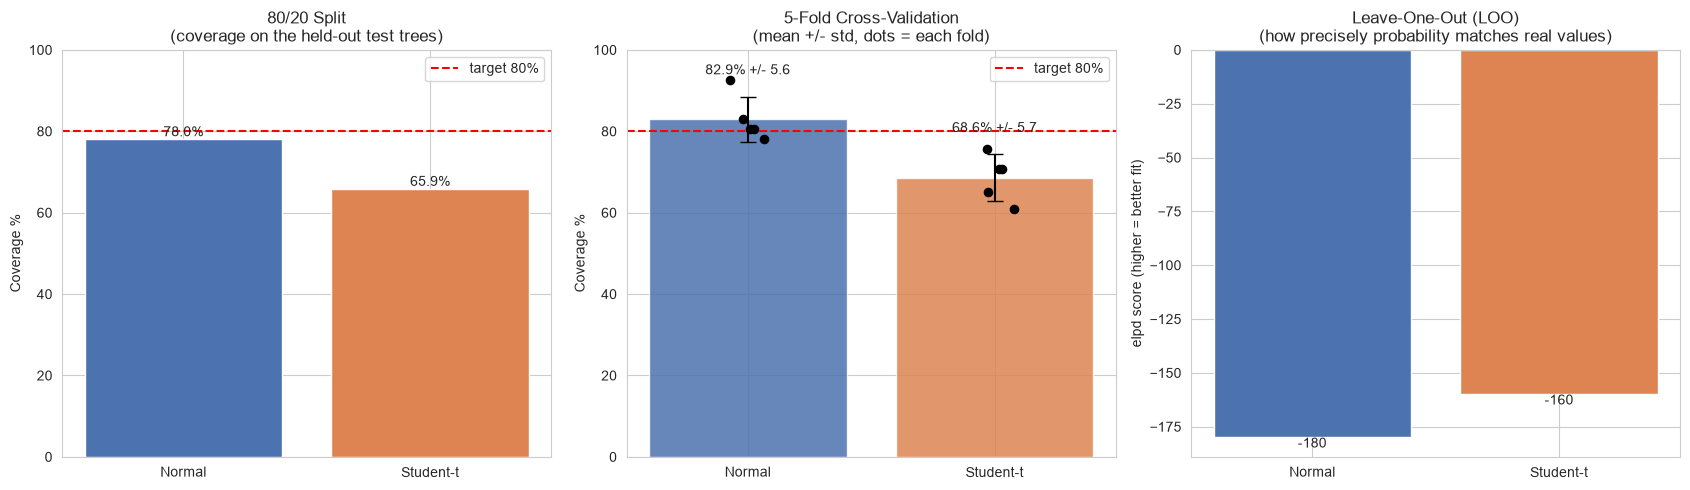


Best on 80/20 split coverage : Normal
Best on 5-fold CV coverage   : Normal
Best on LOO / elpd           : Student-t

Kept: Normal -- calibration (how honest the 80% range actually is) is the property
the model's uncertainty range is used for. LOO measures a different, stricter property
(exact probability placement) and the two can legitimately disagree.


In [14]:
print("===== NORMAL vs STUDENT-T -- combined verdict =====")
display(comparison_table[["Likelihood", "80/20 Split -- Coverage %",
                           "5-Fold CV -- Coverage % (mean +/- std)",
                           "Leave-One-Out -- elpd (+/- se)"]].style.hide(axis="index")
        .set_caption("Note: LOO triggered a Pareto-k warning on this data -- its approximation may be "
                     "less reliable here, treat it as supporting evidence, not decisive on its own.")
        .set_table_styles([{"selector": "caption", "props": [("caption-side", "bottom"), ("font-size", "0.85em"), ("color", "gray")]}]))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = {"Normal": "#4C72B0", "Student-t": "#DD8452"}

ax = axes[0]
bars = ax.bar(comparison_table["Likelihood"], comparison_table["_split_coverage"],
              color=[colors[l] for l in comparison_table["Likelihood"]])
ax.bar_label(bars, fmt="%.1f%%")
ax.axhline(80, color="red", linestyle="--", label="target 80%")
ax.set_ylim(0, 100)
ax.set_ylabel("Coverage %")
ax.set_title("80/20 Split\n(coverage on the held-out test trees)")
ax.legend()

ax = axes[1]
cv_means = cv_summary["mean"]
cv_stds = cv_summary["std"]
bars = ax.bar(cv_means.index, cv_means.values, yerr=cv_stds.values, capsize=6,
              color=[colors[l] for l in cv_means.index], alpha=0.85,
              error_kw={"elinewidth": 1.5, "ecolor": "black"})
ax.bar_label(bars, labels=[f"{m:.1f}% +/- {s:.1f}" for m, s in zip(cv_means.values, cv_stds.values)],
             padding=14)
# overlay each fold's actual point
for likelihood in cv_data["Likelihood"].unique():
    sub = cv_data[cv_data["Likelihood"] == likelihood]
    jitter = np.random.uniform(-0.08, 0.08, size=len(sub))
    x_pos = list(cv_means.index).index(likelihood)
    ax.scatter(x_pos + jitter, sub["Coverage %"], color="black", zorder=5, s=35, label=None)
ax.axhline(80, color="red", linestyle="--", label="target 80%")
ax.set_ylim(0, 100)
ax.set_ylabel("Coverage %")
ax.set_title("5-Fold Cross-Validation\n(mean +/- std, dots = each fold)")
ax.legend()

ax = axes[2]
bars = ax.bar(comparison_table["Likelihood"], comparison_table["_elpd"],
              color=[colors[l] for l in comparison_table["Likelihood"]])
ax.bar_label(bars, fmt="%.0f")
ax.set_ylabel("elpd score (higher = better fit)")
ax.set_title("Leave-One-Out (LOO)\n(how precisely probability matches real values)")

plt.tight_layout()
plt.savefig("report_figures/normal_vs_studentt.png", dpi=130, bbox_inches="tight")
plt.show()

best_split = comparison_table.loc[comparison_table["_split_coverage"].idxmax(), "Likelihood"]
best_cv = cv_summary["mean"].idxmax()
best_loo = comparison_table.loc[comparison_table["_elpd"].idxmax(), "Likelihood"]

print(f"\nBest on 80/20 split coverage : {best_split}")
print(f"Best on 5-fold CV coverage   : {best_cv}")
print(f"Best on LOO / elpd           : {best_loo}")
print(f"\nKept: {best_cv} -- calibration (how honest the 80% range actually is) is the property")
print("the model's uncertainty range is used for. LOO measures a different, stricter property")
print("(exact probability placement) and the two can legitimately disagree.")


## Step 12 — Per-tree prediction quality: does it depend on size, age, or species?

Coverage and R2 give overall numbers. This goes one level deeper: for every one of the 204 trees, how tall is its own predicted curve exactly at the real value (the same idea LOO/elpd uses)? That lets us check whether well-predicted trees tend to be small or large, young or old, or concentrated in one species.

Reuses `trace_full_n` -- the Normal model already fit on 100% of the data for LOO in Step 11 -- so this needs no additional fitting.

**Scale note:** density is computed on the log scale (the scale the model actually fits on), not raw kg -- on raw kg, small trees naturally look "more confident" than large ones purely due to unit scale, which would be misleading.

In [15]:
from scipy.stats import gaussian_kde

corr_full_n = correction_from_fit(trace_full_n, X_log_full, species_idx_full, Y_log_full, df["Species"])
corr_per_tree_n = df["Species"].map(corr_full_n).values
sims_full_n = predict_with_uncertainty(trace_full_n, X_log_full, species_idx_full, corr_per_tree_n)

per_tree_density_log = np.zeros(len(df))
for i in range(len(df)):
    kde_i = gaussian_kde(np.log(sims_full_n[:, i]))
    per_tree_density_log[i] = kde_i(np.log(df["Total_AGB"].iloc[i]))[0]

df["pred_density_log"] = per_tree_density_log
df["size_group"] = pd.qcut(df["Total_AGB"], 3, labels=["Small", "Medium", "Large"])

age_bins_raw = pd.qcut(df["Age"], 3, duplicates="drop")
n_age_bins = age_bins_raw.cat.categories.size
age_labels = ["Young", "Mid", "Old"][:n_age_bins]
df["age_group"] = pd.qcut(df["Age"], 3, labels=age_labels, duplicates="drop")
print(f"Age ended up with {n_age_bins} distinct groups: {age_labels}")

species_palette = dict(zip(unique_species, sns.color_palette("tab10", n_species)))

Age ended up with 3 distinct groups: ['Young', 'Mid', 'Old']


### A few real trees, up close

Same idea as the calibration plot, but per tree: the taller each curve sits exactly at the red line (the real value), the more the model "believed in" what actually happened for that tree.

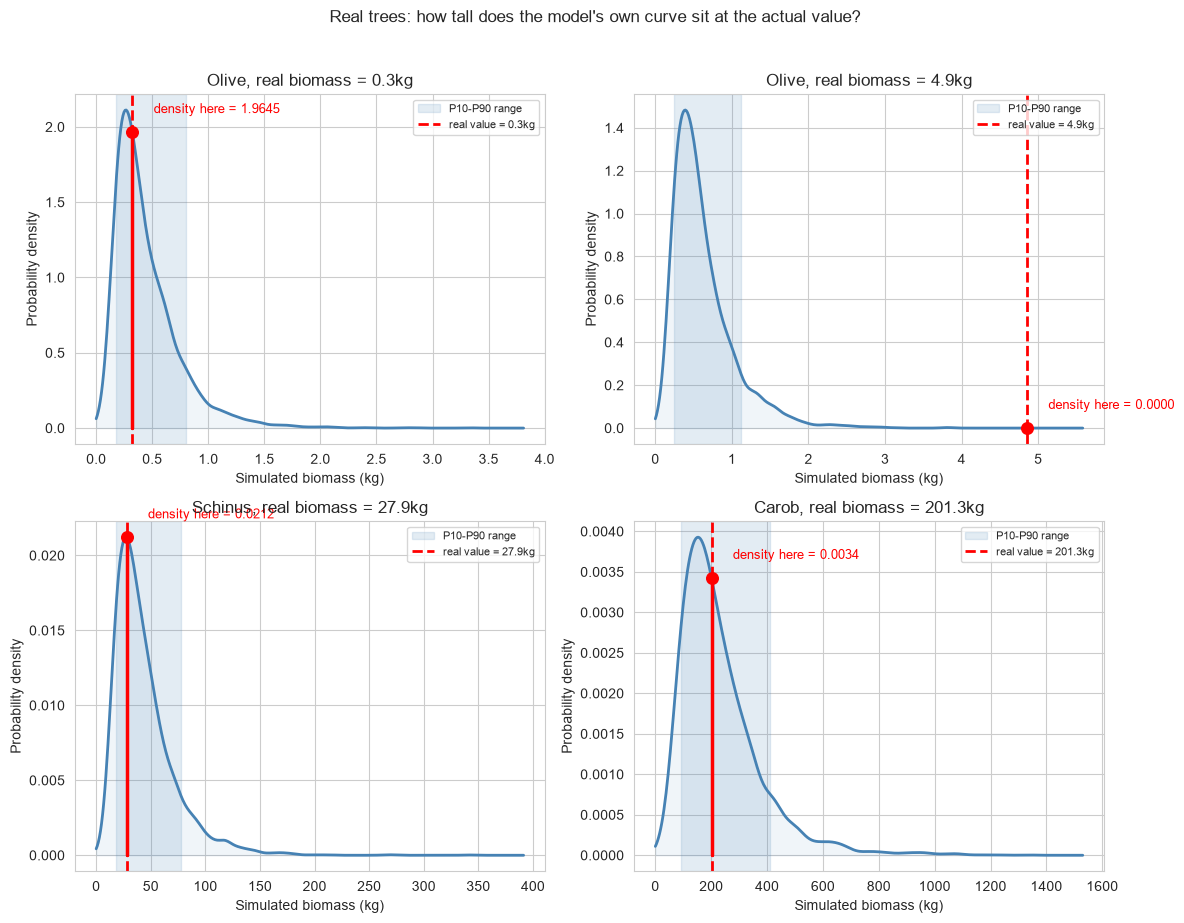

In [16]:
sample_idx = df["Total_AGB"].sort_values().index[[2, len(df)//3, 2*len(df)//3, -3]].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, i in zip(axes, sample_idx):
    real_val = df["Total_AGB"].loc[i]
    sp = df["Species"].loc[i]
    row_pos = df.index.get_loc(i)

    sim_vals = sims_full_n[:, row_pos]
    kde_n = gaussian_kde(sim_vals)
    p10, p90 = np.percentile(sim_vals, [10, 90])
    x_max = max(sim_vals.max(), real_val) * 1.15
    x = np.linspace(0, x_max, 400)
    dens = kde_n(x)
    dens_at_real = kde_n(real_val)[0]

    ax.plot(x, dens, color="steelblue", lw=2)
    ax.fill_between(x, dens, color="steelblue", alpha=0.08)
    ax.axvspan(p10, p90, color="steelblue", alpha=0.15, label="P10-P90 range")
    ax.axvline(real_val, color="red", linestyle="--", lw=2, label=f"real value = {real_val:.1f}kg")
    ax.plot([real_val, real_val], [0, dens_at_real], color="red", lw=2.5)
    ax.scatter([real_val], [dens_at_real], color="red", zorder=5, s=70)
    ax.annotate(f"density here = {dens_at_real:.4f}", xy=(real_val, dens_at_real),
                xytext=(real_val + x_max*0.05, dens_at_real + dens.max()*0.06),
                fontsize=9, color="red")

    ax.set_title(f"{sp}, real biomass = {real_val:.1f}kg")
    ax.set_xlabel("Simulated biomass (kg)")
    ax.set_ylabel("Probability density")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Real trees: how tall does the model's own curve sit at the actual value?", y=1.02)
plt.tight_layout()
plt.savefig("report_figures/tree_density_examples.png", dpi=130, bbox_inches="tight")
plt.show()

### Prediction quality by size class, per species

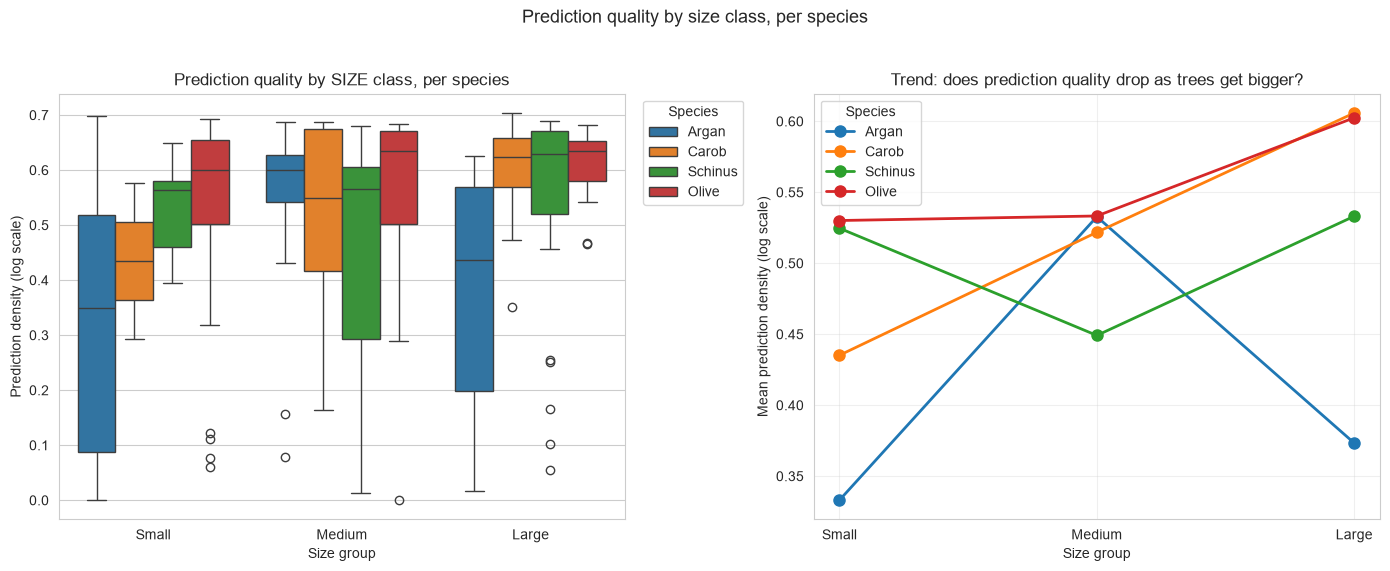

Overall (all species combined) -- mean prediction density by size class:
              mean  count
size_group               
Small       0.4657     68
Medium      0.5051     68
Large       0.5557     68


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.boxplot(data=df, x="size_group", y="pred_density_log", hue="Species",
            palette=species_palette, ax=axes[0])
axes[0].set_xlabel("Size group")
axes[0].set_ylabel("Prediction density (log scale)")
axes[0].set_title("Prediction quality by SIZE class, per species")
axes[0].legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left")

trend = df.groupby(["size_group", "Species"], observed=True)["pred_density_log"].mean().reset_index()
for sp in unique_species:
    sub = trend[trend["Species"] == sp]
    axes[1].plot(sub["size_group"], sub["pred_density_log"], marker="o", markersize=8,
                 color=species_palette[sp], label=sp, linewidth=2)
axes[1].set_xlabel("Size group")
axes[1].set_ylabel("Mean prediction density (log scale)")
axes[1].set_title("Trend: does prediction quality drop as trees get bigger?")
axes[1].legend(title="Species")
axes[1].grid(alpha=0.3)

plt.suptitle("Prediction quality by size class, per species", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig("report_figures/quality_by_size_species.png", dpi=130, bbox_inches="tight")
plt.show()

overall_trend = df.groupby("size_group", observed=True)["pred_density_log"].agg(["mean", "count"]).round(4)
print("Overall (all species combined) -- mean prediction density by size class:")
print(overall_trend)

**Reading the result:** if one species' line slopes downward while the others slope upward, that species specifically gets *harder* to predict as trees grow, unlike the rest -- worth naming explicitly rather than letting it blend into an overall average.

## Step 13 — Predicting brand new trees

In [18]:
def predict_new_trees(new_df, trace, correction_by_species, predictors=PREDICTORS):
    new_species_idx = new_df["Species"].map(species_to_idx).values
    new_X_log = np.log(new_df[predictors].values)
    new_correction = new_df["Species"].map(correction_by_species).values

    beta0_m = trace.posterior["beta0"].mean(("chain", "draw")).values
    betas_m = trace.posterior["betas"].mean(("chain", "draw")).values
    b = BRAMBLE({"betas": betas_m, "beta0": beta0_m}, inference=False)
    return b.predict_biomass(new_X_log, new_species_idx, correction=new_correction)

# new_df can be a new species, e.g. the hawthorn destructive data

## Step 14 — Export a Markdown report

In [20]:
report_path = "BRAMBLE_report.md"

def df_to_md_table(d, float_fmt="{:.2f}"):
    d = d.copy()
    for col in d.columns:
        if pd.api.types.is_float_dtype(d[col]):
            d[col] = d[col].map(lambda v: float_fmt.format(v))
    header = "| " + " | ".join(str(c) for c in d.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(d.columns)) + " |"
    rows = ["| " + " | ".join(str(v) for v in row) + " |" for row in d.values]
    return "\n".join([header, sep] + rows)

perf_table_md = df_to_md_table(perf)
comparison_md = df_to_md_table(comparison_table[["Likelihood", "80/20 Split -- Coverage %",
                                                    "5-Fold CV -- Coverage % (mean +/- std)",
                                                    "Leave-One-Out -- elpd (+/- se)"]])

weakest_sp = perf.loc[perf["R2"].idxmin(), "Species"]
strongest_sp = perf.loc[perf["R2"].idxmax(), "Species"]
weakest_r2 = perf.loc[perf["R2"].idxmin(), "R2"]
strongest_r2 = perf.loc[perf["R2"].idxmax(), "R2"]

report = f"""# BRAMBLE Model Report

A hierarchical Bayesian model predicting tree biomass (kg) from height (Ht) and crown
diameter (CD), fit separately per species but sharing statistical strength across species
(partial pooling). This report walks through what was built, how it was checked, and what
the results actually mean -- not just the numbers, but why each check exists.

## 1. Data
- Total trees: {len(df)}
- Species: {", ".join(unique_species)}
- Predictors: {", ".join(PREDICTORS)}
- Train / test split: {len(df_train)} / {len(df_test)} trees (80/20, stratified by species
  so each species keeps its own proportion in both sets)

## 2. Model

    log(biomass) = beta0_species + b1_species*log(Ht) + b2_species*log(CD) + error

Biomass grows with size roughly as a power law, so fitting on the log scale turns that curve
into a straight line and keeps the error term's spread proportional to tree size rather than
constant in kg (which would badly overstate uncertainty for small trees and understate it for
large ones). Each species gets its own intercept and slopes, but those coefficients are drawn
from a shared population-level distribution -- species with fewer trees (Argan) borrow
statistical strength from the others instead of being fit in isolation. The model is fit with
MCMC (NUTS sampler in PyMC), using a non-centered parameterization, a numerical trick that only
helps the sampler converge and does not change what is being estimated.

## 3. Convergence (Step 7)
- Divergences: {divergences} (0 is ideal; a handful out of thousands of draws is not a concern)
- Max R-hat: {summary["r_hat"].max():.3f} (target: as close to 1.00 as possible -- means the 4
  independent chains agree with each other)
- Min ESS: {summary["ess_bulk"].min():.0f} (effective sample size -- how many *independent*
  posterior draws the chains produced; higher is more precise)

These three numbers together say the sampler actually explored the posterior properly and the
fit can be trusted -- if any of them looked bad, nothing downstream would be reliable.

## 4. Overall + per-species performance (Step 9, training data)

**Overall (all species combined):** R2 = {r2_train:.3f}, RMSE = {rmse_train:.2f} kg,
CV% = {cv_pct_train:.1f}%, Coverage = {cov_train:.1f}% (target ~80%).

An overall number can hide a species-specific weakness -- a few well-predicted species can
compensate for one badly-predicted one and the average would still look fine. The table below
splits the same predictions out by species:

{perf_table_md}

**Strongest fit:** {strongest_sp} (R2 = {strongest_r2:.3f}). **Weakest fit:** {weakest_sp}
(R2 = {weakest_r2:.3f}) -- Ht and CD alone carry little information for this species; see the
known limitation at the end of this report.

The figure below shows every tree's real biomass (x-axis) against the model's median
prediction (y-axis), with a bar for its P10-P90 uncertainty range, first for all species
pooled together and then one panel per species. A species with dots hugging the red 1:1 line
and narrow bars is one the model understands well from Ht+CD alone; a species with scattered
dots or wide bars relative to its size is one where those two predictors are not enough.

![Observed vs Predicted, overall and per species](report_figures/obs_vs_pred_per_species.png)

## 5. Calibration check (Step 8)

Coverage tells us *how often* the real value lands inside the predicted P10-P90 range,
but it can hide a lopsided pattern (e.g. systematically landing too high or too low even while
averaging to the right percentage). The histogram below shows, for every tree, where its real
value landed as a percentile of its own simulated distribution -- if the model is well
calibrated this should scatter evenly across 0-100. The scatter plot next to it is the same
observed-vs-predicted check as above, but on the full training set with the calibration
context.

![Calibration](report_figures/calibration.png)

## 6. Held-out test set (Step 10)

Training-set calibration can look good partly because the model was fit on those exact trees.
The real test is trees the model never saw during fitting:
- R2: {test_r2:.3f}
- RMSE: {test_rmse:.2f} kg
- Coverage: {cov_test:.1f}% (target ~80%)

With only {len(df_test)} held-out trees, a single split's coverage number can swing quite a bit
just from which trees happened to land in the test set -- Section 8 checks this properly with
repeated cross-validation instead of relying on one split.

## 7. Per-tree prediction quality (Step 12)

Beyond one aggregate coverage number, this checks whether prediction quality depends on a
tree's size, age, or species -- i.e. whether the model is quietly worse for small trees, old
trees, or one particular species, which the aggregate numbers above would not reveal.
"Prediction density" here is how much probability mass the model puts exactly on the tree's
real value (computed on the log scale, so it is comparable across small and large trees alike).

![A few real trees, up close](report_figures/tree_density_examples.png)
![Prediction quality by size class, per species](report_figures/quality_by_size_species.png)

**Reading the boxplot:** dots outside a box are trees whose real value fell in a low-probability
region of their own predicted distribution -- i.e. trees the model predicted badly, not
necessarily trees outside their P10-P90 range (a related but stricter check). A species whose
line trends downward as trees get larger, while the others trend upward, is a species where the
model's confidence does not scale correctly with size -- watch for {weakest_sp} here.

## 8. Normal vs Student-t likelihood comparison (Step 11)

The error term's shape (Normal vs Student-t, which has fatter tails and tolerates outlier trees
more easily) was compared three ways, because any single validation method can mislead on its
own:
- **80/20 split** -- coverage on the fixed held-out test set (Section 6).
- **5-fold cross-validation** -- 5 real refits, every tree held out exactly once, stratified by
  species; the most robust calibration check since it is not sensitive to one arbitrary split.
- **Leave-one-out (PSIS-LOO)** -- approximate leave-one-out on the full dataset, scored by ELPD
  (expected log predictive density): a stricter, different property than calibration -- how
  precisely probability mass is placed on the exact observed value, rather than whether the
  stated uncertainty range is honest.

{comparison_md}

![Normal vs Student-t](report_figures/normal_vs_studentt.png)

**Verdict:** kept **{best_cv}** -- decided on 5-fold CV coverage, the validation method least
sensitive to any single arbitrary split, and the property the model's P10-P90 output is
actually used for. LOO/ELPD favored {best_loo}, and that is a real, non-trivial difference on
that specific metric -- but LOO triggered a Pareto-k warning on this data (its own diagnostic
flagging the approximation as less reliable here), and calibration and ELPD are two legitimately
different properties of the same fitted distribution that can disagree without either being
wrong. Calibration was chosen as the deciding factor because it is what the reported uncertainty
range is used for downstream.

## 9. Known limitation / next step

**{weakest_sp}** remains the weakest species (R2 = {weakest_r2:.3f} with Ht+CD alone); it also
needed the largest bias-correction factor when back-transforming from the log scale. This is not
a problem with the model itself (the hierarchy, priors, and sampler are all behaving correctly)
-- it is that height and crown diameter alone do not distinguish {weakest_sp} trees well. Adding
basal diameter (BD) as a third predictor is the identified next step, specifically for this
species, and has not yet been applied in this version of the model.
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print(f"Report written to: {report_path}")
print(f"Figures saved in: report_figures/")
print("Open the .md file in VS Code, or convert to PDF/Word from there.")

Report written to: BRAMBLE_report.md
Figures saved in: report_figures/
Open the .md file in VS Code, or convert to PDF/Word from there.


## Conclusion

- **Model:** hierarchical Bayesian, log-linear, Normal likelihood, species partially pooled.
- **Convergence:** clean (Step 7).
- **80/20 test set (Step 10):** one honest but single-split check on genuinely unseen trees.
- **Normal vs Student-t (Step 11):** decided using calibration (5-fold CV coverage) and LOO/elpd together, not separately — Normal wins on calibration (the property the uncertainty range is actually used for), Student-t wins on elpd (precision of fit); Normal is kept.
- **Known limitation:** Argan remains the weakest species with Ht+CD alone (Step 9); adding basal diameter is the identified next step.